In [20]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from chat_bots import ChatAnaliseTecnica,  ChatSentimento, ChatValuation, ChatFundamentalistas
from tratando_dados import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from chat_bots import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=api_key,
    model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    # RETIRE THE TICKER DO PROMPT INITIAL
    messages: Annotated[list, add_messages]
    ticker: str 
    method_analysis: str  
    
    
class ModeloAnaliseTecnica():
    def __init__(
        self,
        state: State,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = ChatAnaliseTecnica(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response

class ModeloValuation:
    def __init__(
        self,
        state:State,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = ChatValuation(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )

        return response
    

class ModeloSentimento:
    def __init__(
        self,
        state:State,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = ChatSentimento(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response


class ModeloFundamentos:
    def __init__(
        self,
        state: State,
        stream: bool = False,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        dados_inicio: str = "2021-01-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    def dados_fundamentalistas(self) -> List[Any]:
        return tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = self.dados_fundamentalistas()
        response = ChatFundamentalistas(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response


def process_technical(state: State) -> State:
    try:
        modelo = ModeloAnaliseTecnica(state=state)
        response = modelo.chat_analise_tecnica()
        new_state = state.copy()
        new_state["messages"].append(AIMessage(content=response)) 
        return new_state
    except Exception as e:
        print(f"Erro no processamento de analise tecnica: {str(e)}")
        pass
    

def process_valuation(state: State) -> State:
    """
    Processa a análise de valuation e atualiza o estado.
    """
    try:
        modelo = ModeloValuation(state=state)
        response = modelo.chat_valuation()
        
        # Criar novo estado com as atualizações
        new_state = state.copy()
        
        # Adicionar a resposta ao histórico de mensagens
        new_state["messages"] = list(state["messages"])
        new_state["messages"].append(AIMessage(content=response))
        
        return new_state
        
    except Exception as e:
        print(f"Erro no processamento de analise de valuation: {str(e)}")
        pass
    
def process_sentimetal(state: State) -> State:
    try:
        modelo = ModeloSentimento(state=state)
        response= modelo.chat_sentimento()
        
        new_state = state.copy()
        new_state["messages"] = list(state["messages"])
        new_state["messages"].append(AIMessage(content=response))
        
        return new_state
    except Exception as e:
        print(f"Erro no processamento de analise de sentimento: {str(e)}")
        pass
    
def process_fundamental(state: State) -> State:
    try:
        modelo = ModeloFundamentos(state=state)
        response = modelo.chat_fundamentalistas()
        next_state = state.copy()
        next_state["messages"] = list(state["messages"])
        next_state["messages"].append(AIMessage(content=response))
        return next_state
    except Exception as e:
        print(f"Erro no processamento de fundamentos: {str(e)}")
        pass
    
    
def pegando_empresa_ticker():
    dados_empresas = dados = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    empresas = dados_empresas['Empresa'].tolist()
    tickers = dados_empresas['tic'].tolist()
    
    return empresas, tickers
    
def chat_input(state: State) -> State:
    # Carrega dados das empresas
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    # Template do prompt
    prompt = """
    Você é um assistente especializado em investimentos. Por favor, extraia as seguintes informações da mensagem do usuário:
    1. O ticker (código) da ação
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical)
    3. Se não houver o método, retorne chatbot para continuar a conversa
    4. Se não houver o ticker, mas tiver o nome da empresa, procure no {empresas_tickers} o ticker correspondente ao nome da empresa
    
    Responda apenas com o ticker e o método no formato:
    TICKER: <ticker>
    MÉTODO: <método>
    """
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    
    # Fazer a chamada ao LLM
    response = llm.invoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    
    ticker = ''
    metodo_analise = ''
    
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()   
        
    if ticker and ticker not in empresas_df['tic'].to_list():
        ticker = ""
    
    # Update state
    state['ticker'] = ticker
    state['method_analysis'] = metodo_analise
    
    return state

def should_continue(state: State):
    if state["method_analysis"] == "technical":
        return 'technical'
    if state['method_analysis'] == 'valuation':
        return 'valuation'
    if state['method_analysis'] == 'sentimental':
        return 'sentimental'
    if state['method_analysis'] == "fundamentals" :
        return "fundamentals"
    return "chatbot"

graph_builder = StateGraph(State)

def chatbot(state: State) -> dict:
    """
    Processa as mensagens do usuário e retorna uma resposta formatada.
    """
    try:
        # Criar o prompt do sistema
        system_message = SystemMessage(content="""
        Você é um assistente especializado em análise de investimentos.
        Ajude o usuário com análises e informações sobre investimentos.
        Se não for perguntado nada de investimentos, volte ao chatbot e converse normalmente.
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        # Fazer a chamada ao LLM
        response = llm.invoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
 
        }
        
memory = MemorySaver()

graph_builder.add_node("chat_input", chat_input)
graph_builder.add_node("technical", process_technical)
graph_builder.add_node('valuation', process_valuation)
graph_builder.add_node('sentimental', process_sentimetal)
graph_builder.add_node('fundamentals', process_fundamental)

graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chat_input")
graph_builder.add_conditional_edges(
    "chat_input",
    should_continue,
    {
        "technical": "technical",
        "valuation":"valuation",
        "sentimental":"sentimental",
        "fundamentals":"fundamentals",
        "chatbot": "chatbot",        
    },
)

#graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("technical",END)
graph_builder.add_edge("valuation",END)
graph_builder.add_edge("sentimental", END)
graph_builder.add_edge("fundamentals", END)
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(checkpointer=memory)

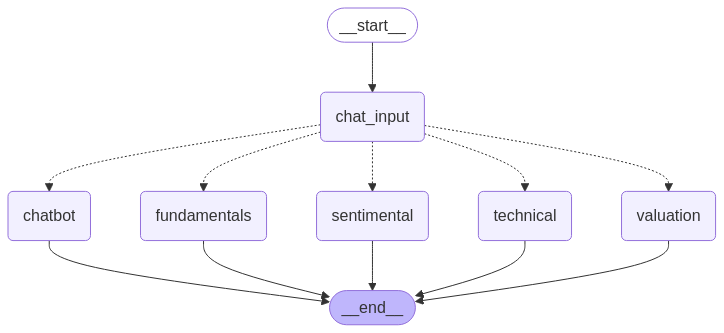

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [24]:

user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    initial_state = {
            "messages": [HumanMessage(content=mess)],
            "ticker": "",  # Definindo o ticker explicitamente
            "method_analysis": "" , # Definindo o método de análise|
            
        }
    events = graph.invoke(
            initial_state,
            config=config,
            stream_mode="values",
        )
    

from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()
    

$ITUB4.SA: possibly delisted; no price data found  (period=18y)


Erro no processamento de analise tecnica: index 0 is out of bounds for axis 0 with size 0
Erro no processamento de fundamentos: stream timeout
Erro no processamento de fundamentos: upstream request timeout
Erro no processamento de fundamentos: upstream request timeout
Erro no processamento de fundamentos: upstream request timeout
Erro no processamento de fundamentos: upstream request timeout
Não foi possível pegar os links da pagina 1!
Não foi possível pegar os titulos da pagina 1!
Não foi possível pegar as fontes da pagina 1!
Não foi possível pegar as datas da pagina 1!
Sem mais páginas!
Poucas noticias encontrada para o ticker FIQE3 no Yahoo Finance. Buscando noticias no Google
Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/acoes/relatorios/unifique-fiqe3-resultados-em-linha-no-2t24/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Erro no processamento de analise de sentimento: upstream request timeout


[*********************100%***********************]  1 of 1 completed


Nao tem returnOnEquity
Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

...

Diferença entre valuation e cotação: -267.41%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -16.21%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Erro no processamento de analise de valuation: upstream request timeout
================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================

Bom dia! Estou bem, obrigado por perguntar. Como posso ajudar você hoje? Se você tiver alguma dúvida sobre investimentos ou qualquer outro assunto, estou à disposição.

================================ Human Message =================================

Olá, poderia me ajudar?

================================== Ai Message ==================================

Claro, olá! Como posso ajudar você hoje? Se você tiver alguma dúvida ou precisar de informações sobre investimentos, estou aqui para auxiliar. Caso contrário, posso conversar sobre outros assuntos.

================================ Human Message =================================

Boa tarde, gostaria de algumas análises

================================== Ai Message =================